Cell for synchronisation

In [1]:
%load_ext autoreload
%autoreload 2

Feature extraction

In [5]:
import pickle 
from pathlib import Path
import numpy as np
from src.feature_generation import pool_features
dir = Path("/idiap/temp/adeych/data")
with open(dir / "feature_banks" / "perch2-bags.pkl", "rb") as f:
    X_bags = pickle.load(f)

y = np.load(dir / "feature_banks" / "labels.npy")
X_bags_pooled = pool_features(X_bags,encoder = 'perch2')

Testing Algorithms

In [ ]:
from src.mil_multilabel_new_new import abmil_classifier_quick
variants = ('ABMIL_LSTM_residual',)
quick_results = abmil_classifier_quick(
       X_bags_pooled, y, num_trials=1,
       variants=variants,
)

In [19]:
from src.mil_multilabel_new_new import abmil_classifier_tuned_optuna
results2 = abmil_classifier_tuned_optuna(X_bags_pooled, y, n_split_out=5, n_split_in=5, num_trials=1,
                                   random_state=42, n_optuna_trials=1, n_epochs_max=15,
                                   variants=('ABMIL_LSTM',),
                                   ensemble=True, ensemble_labels=(0,),
                                   ensemble_n_optuna_trials=1, ensemble_n_split_in=3,
                                   ensemble_n_epochs_max=15)

[I 2026-09-01 14:47:22,870] A new study created in memory with name: ABMIL_LSTM_trial0_fold0


Starting Trial 1/1 with random_state=42...
  Tuning and evaluating model: ABMIL_LSTM
    Evaluating fold 1/5
Start inner loop)
Inner loop number 1
Inner loop number 2
Inner loop number 3
Inner loop number 4
Inner loop number 5


[I 2026-09-01 14:48:24,010] Trial 0 finished with value: 0.9714434340935219 and parameters: {'dropout': 0.3, 'learning_rate': 0.0005, 'weight_decay': 1e-05, 'batch_size': 4, 'hidden_dim': 128, 'attention_dim': 64}. Best is trial 0 with value: 0.9714434340935219.


End inner loop)
4
0.9769855111891846


[I 2026-09-01 14:48:37,774] A new study created in memory with name: ensemble_linear_probe_seed42
[I 2026-09-01 14:48:38,804] Trial 0 finished with value: 0.5184788153960044 and parameters: {'learning_rate': 0.005, 'weight_decay': 1e-05, 'batch_size': 4}. Best is trial 0 with value: 0.5184788153960044.
[I 2026-09-01 14:48:39,490] A new study created in memory with name: ABMIL_LSTM_trial0_fold1


    Evaluating fold 2/5
Start inner loop)
Inner loop number 1
Inner loop number 2
Inner loop number 3
Inner loop number 4


[W 2026-09-01 14:49:23,063] Trial 0 failed with parameters: {'dropout': 0.3, 'learning_rate': 0.0001, 'weight_decay': 1e-05, 'batch_size': 4, 'hidden_dim': 128, 'attention_dim': 64} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/idiap/temp/adeych/conda/envs/temp-env-4/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/remote/idiap.svm/home.active/adeych/bat-project/src/mil_multilabel_new_new.py", line 1305, in objective
    _, history, _ = train_abmil(
                    ^^^^^^^^^^^^
  File "/remote/idiap.svm/home.active/adeych/bat-project/src/mil_multilabel_new_new.py", line 736, in train_abmil
    y_bag = y_batch[bag_idx].to(device)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
[W 2026-09-01 14:49:23,064] Trial 0 failed with value None.


KeyboardInterrupt: 

Importing results

In [2]:
import pickle

with open("/idiap/temp/adeych/results/Hyprangecurve_experiment/mil_ABMIL_LSTM_results_si_3.pkl", "rb") as f:
    results_ABMIL_LSTM = pickle.load(f)

with open("/idiap/temp/adeych/results/Hyprangecurve_experiment/mil_ABMIL_results_si_3.pkl", "rb") as f:
    results_ABMIL = pickle.load(f)

with open("/idiap/temp/adeych/results/Hyprangecurve_experiment/mil_LSTM_results_si_3.pkl", "rb") as f:
    results_LSTM = pickle.load(f)  

with open("/idiap/temp/adeych/results/Hyprangecurve_experiment/mil_Linear_results_si_3.pkl", "rb") as f:
    results_Linear = pickle.load(f) 

with open("/idiap/temp/adeych/results/Hyprangecurve_experiment/mil_ABMIL_LSTM_results_en_3.pkl", "rb") as f:
    results_ABMIL_LSTM1 = pickle.load(f)

with open("/idiap/temp/adeych/results/Hyprangecurve_experiment/mil_ABMIL_results_en_3.pkl", "rb") as f:
    results_ABMIL1 = pickle.load(f)

with open("/idiap/temp/adeych/results/Hyprangecurve_experiment/mil_LSTM_results_en_3.pkl", "rb") as f:
    results_LSTM1 = pickle.load(f) 

with open("/idiap/temp/adeych/results/fc_experiment/mil_Mean_results_si_6.pkl", "rb") as f:
    results_Mean = pickle.load(f)

with open("/idiap/temp/adeych/results/fc_experiment/mil_Mean_results_en_6.pkl", "rb") as f:
    results_Mean1 = pickle.load(f) 



/idiap/temp/adeych/conda/envs/temp-env-4/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import pickle
#
#with open("/idiap/temp/adeych/results/fc_experiment/mil_ABMIL_LSTM_results_si_4.pkl", "rb") as f:
#    results_ABMIL_LSTM = pickle.load(f)
#
#with open("/idiap/temp/adeych/results/fc_experiment/mil_ABMIL_results_si_4.pkl", "rb") as f:
#    results_ABMIL = pickle.load(f)
#
#with open("/idiap/temp/adeych/results/fc_experiment/mil_LSTM_results_si_4.pkl", "rb") as f:
#    results_LSTM = pickle.load(f) 
#
with open("/idiap/temp/adeych/results/fc_experiment/mil_ABMIL_LSTM_proj_results_si_5.pkl", "rb") as f:
    results_ABMIL_LSTM_proj = pickle.load(f)
#
#with open("/idiap/temp/adeych/results/fc_experiment/mil_LSTM_proj_results_si_5.pkl", "rb") as f:
#    results_LSTM_proj = pickle.load(f)   
#
#with open("/idiap/temp/adeych/results/Hyprangecurve_experiment/mil_Linear_results_si_3.pkl", "rb") as f:
#    results_Linear = pickle.load(f)  
#
#with open("/idiap/temp/adeych/results/fc_experiment/mil_ABMIL_LSTM_results_en_4.pkl", "rb") as f:
#    results_ABMIL_LSTM1 = pickle.load(f)
#
#with open("/idiap/temp/adeych/results/fc_experiment/mil_ABMIL_results_en_4.pkl", "rb") as f:
#    results_ABMIL1 = pickle.load(f)

#with open("/idiap/temp/adeych/results/fc_experiment/mil_LSTM_results_en_4.pkl", "rb") as f:
#    results_LSTM1 = pickle.load(f) 

with open("/idiap/temp/adeych/results/fc_experiment/mil_ABMIL_LSTM_proj_results_en_5.pkl", "rb") as f:
    results_ABMIL_LSTM_proj1 = pickle.load(f)

with open("/idiap/temp/adeych/results/fc_experiment/mil_LSTM_proj_results_en_5.pkl", "rb") as f:
    results_LSTM_proj1 = pickle.load(f) 

Analysing results

Hyperparameters

In [ ]:
from src.analysis_utils import collect_results, plot_loss_curves, hyperparam_performance_summary,hyperparam_range_summary

all_results = results_ABMIL1

main_df, simple_df = collect_results(all_results)          # or all_results, variant='ABMIL_LSTM_residual_proj'

main_summary = hyperparam_performance_summary(main_df)       # dict: hyperparam -> mean/std/count fold_AP, sorted best-first
range_summary = hyperparam_range_summary(main_df, bins=5)
main_summary['learning_rate']

#1e-4 lr for ensemble and 1e-4 for simple model seems to be the best.
#from experience, fc layer needed otherwise worse performance (especially abmil) and residual connection needed

,mean,std,count
learning_rate,,,
0.00005,0.972890,0.012904,6
0.00010,0.963522,0.019952,8
0.00050,0.956925,0.008839,6
0.00100,0.956557,0.015334,5


In [ ]:
from src.analysis_utils import collect_results, plot_hyperparameter_pairplot
all_results = results_ABMIL1
main_df, simple_df = collect_results(all_results)

plot_hyperparameter_pairplot(main_df)   # auto-detects the 5 varying hyperparams -> 5x5 grid
plot_hyperparameter_pairplot(simple_df)

Loss curves

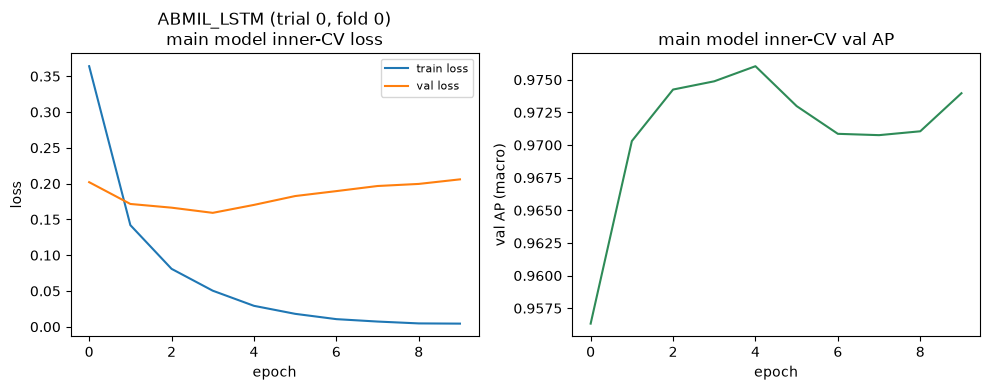

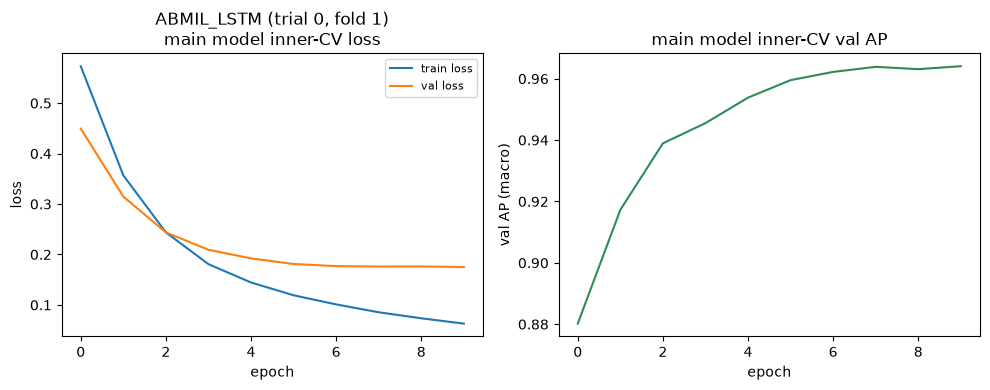

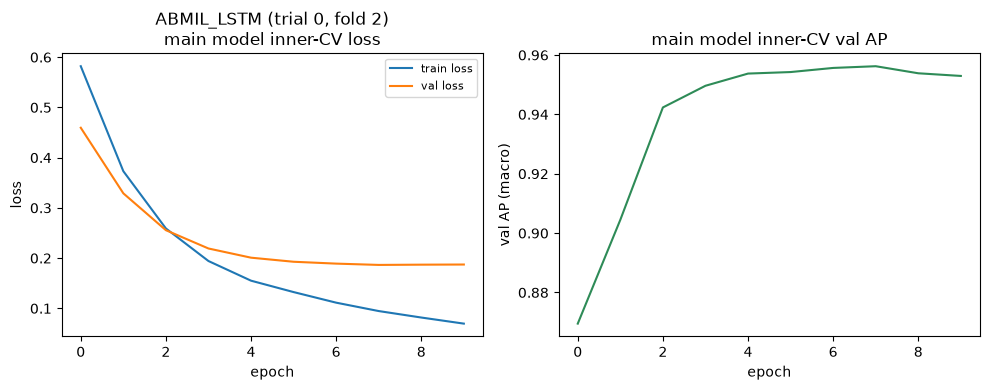

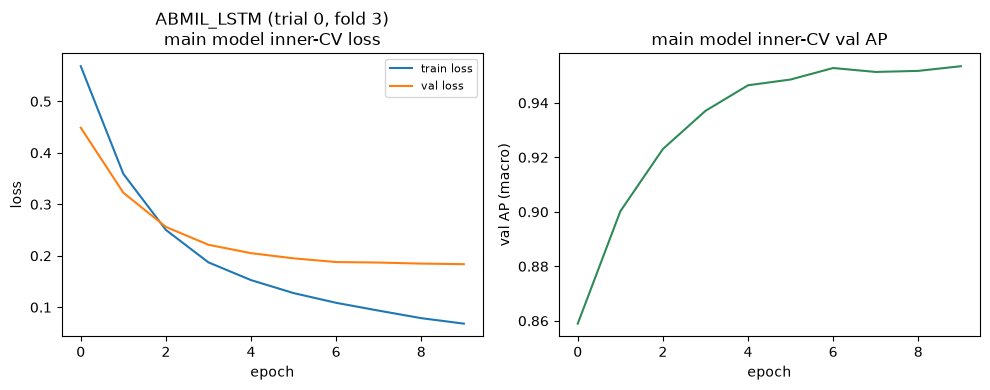

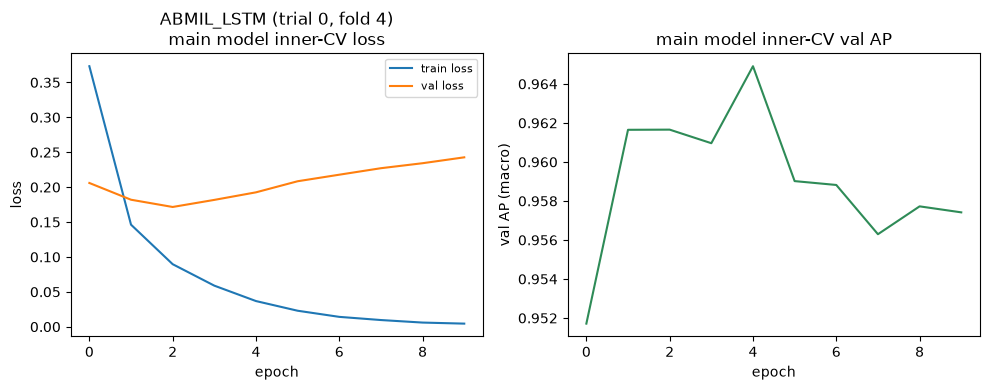

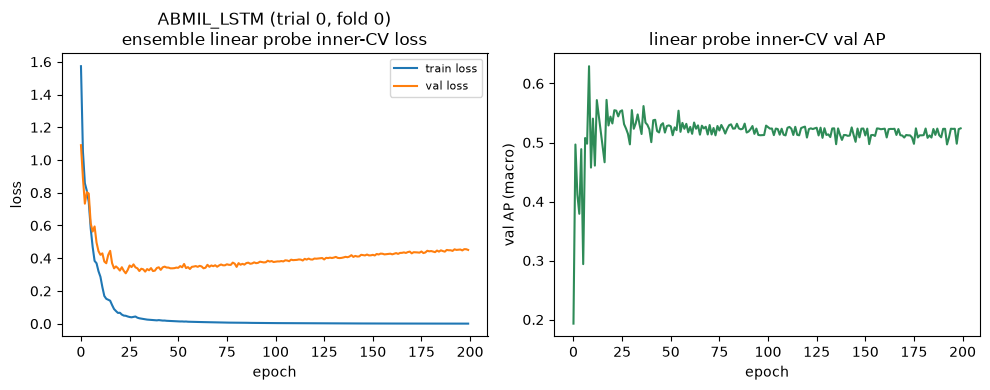

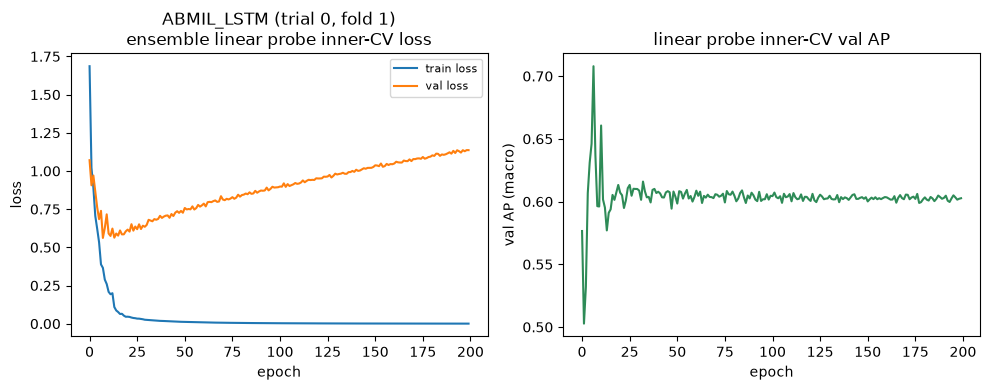

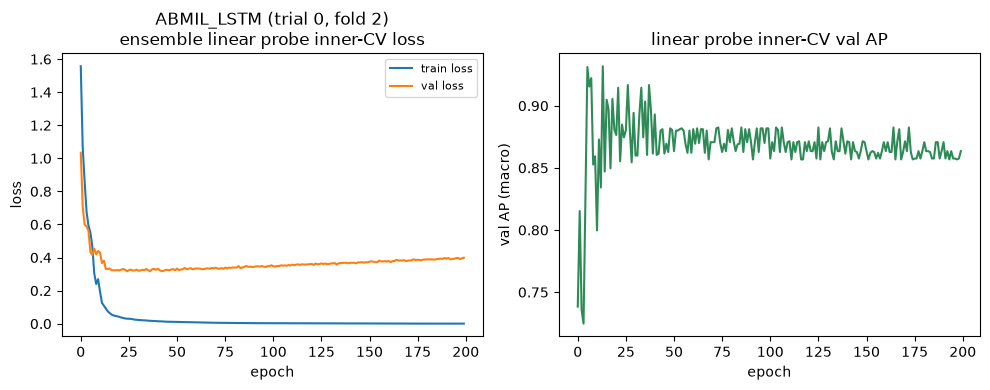

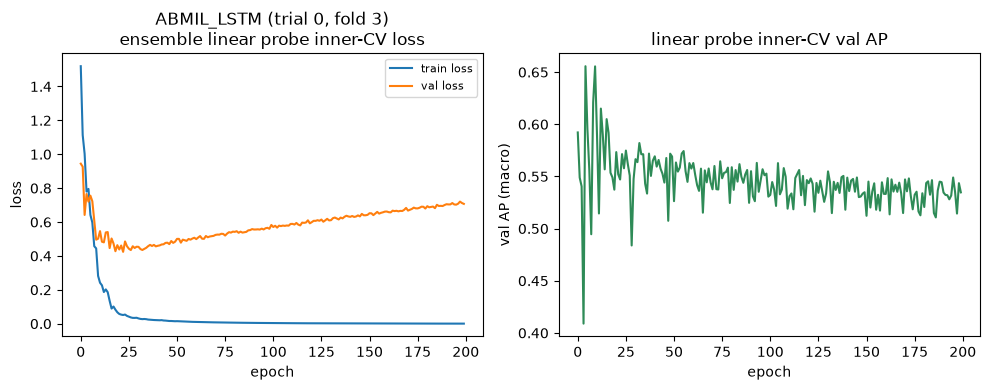

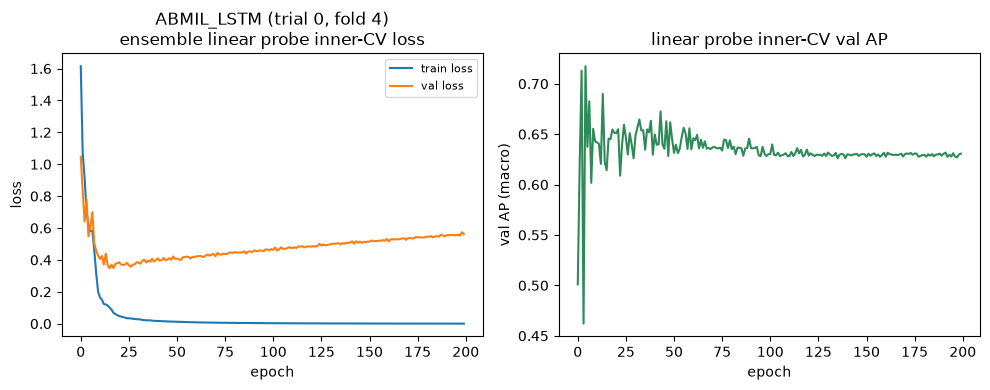

In [15]:
from src.analysis_utils import plot_inner_cv_curves

plot_inner_cv_curves(results2, max_folds = 5, include_ensemble = True)

Results plot

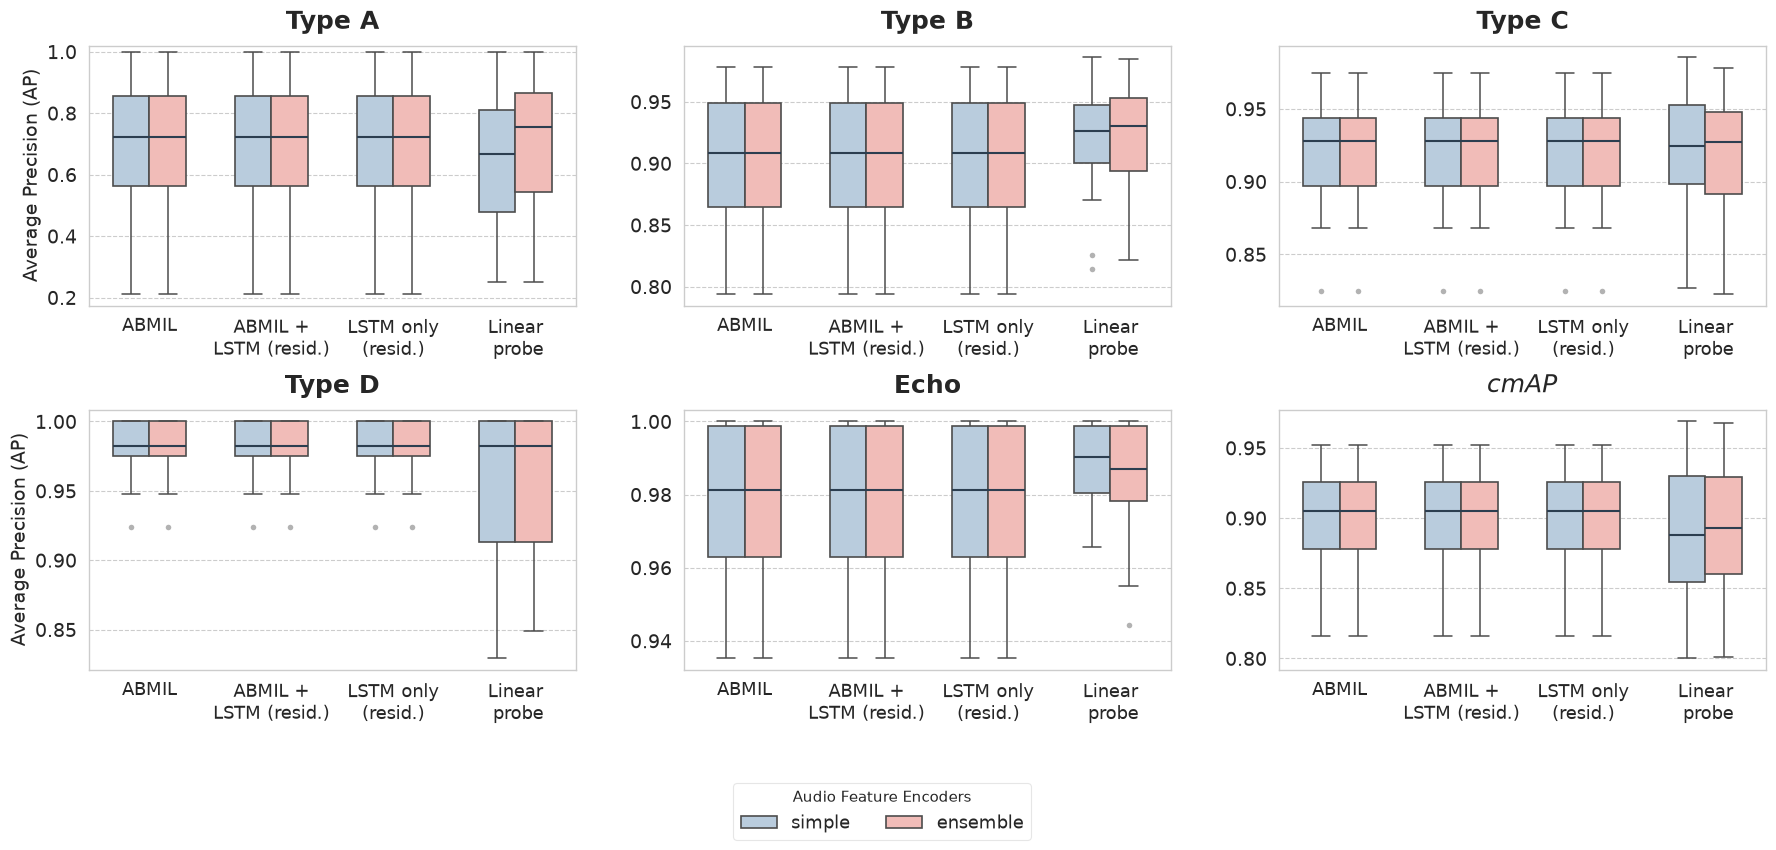

In [15]:
from src.plot_variant_comparison import plot_variant_comparison_boxplots
#results_abmil_0 = {
#    'simple': results_ABMIL ,
#    'ensemble': results_ABMIL,
#    #'effnetb0': results_ABMIL1,
#}
results_abmil_lstm_residual_0 = {
    'simple': results_Linear,
    'ensemble':results_Linear,
    #'effnetb0': results_ABMIL_LSTM_proj1,
}
#results_lstm_residual_0 = {
#    'simple': results_LSTM,
#    'ensemble': results_LSTM_proj,
#    #'effnetb0': results_LSTM_proj1,
#}
results_linear = {
    'simple': results_Mean,
    'ensemble': results_Mean1,
    #'effnetb0': results_Linear,
}


#plot_variant_comparison_boxplots(
#    results_abmil_0, results_abmil_lstm_residual_0,
#    results_lstm_residual_0,results_linear,
#)

plot_variant_comparison_boxplots(
    results_abmil_lstm_residual_0, results_abmil_lstm_residual_0, results_abmil_lstm_residual_0, results_linear
)

Printing results tables

In [19]:
from src.algo_comparison1 import architecture_comparison_latex_tables
table1, table2 = architecture_comparison_latex_tables(
    results_ABMIL1, results_ABMIL_LSTM1, results_Mean1,results_LSTM1, results_Linear,
    results_ABMIL, results_ABMIL_LSTM, results_Mean,results_LSTM,
)

Statistical analysis algorithms


=== Encoder: perch2 -- which MIL variant works best? (Friedman + Nemenyi) ===
[perch2] Number of matched blocks (N): 125
[perch2] Variants compared: ['ABMIL', 'ABMIL_LSTM_residual', 'LSTM_only_residual', 'LSTM_last', 'Mean_only']
[perch2] Friedman chi^2 statistic: 55.1786 | p-value: 2.9807e-11
[perch2] Result: Significant difference detected (p < 0.05). Running Nemenyi post-hoc test.
[perch2] Mean ranks (rank 1 = best): ABMIL=2.444, ABMIL_LSTM_residual=2.528, LSTM_only_residual=3.220, LSTM_last=3.440, Mean_only=3.368
[perch2] Best-ranked variant: ABMIL
[perch2] Nemenyi Critical Difference (CD): 0.5456
[perch2] Nemenyi pairwise p-value matrix:
                         ABMIL  ABMIL_LSTM_residual  LSTM_only_residual  LSTM_last  Mean_only
ABMIL                   1.0000               0.9935          9.9037e-04 6.3028e-06 3.7746e-05
ABMIL_LSTM_residual     0.9935               1.0000              0.0049 5.0228e-05 2.5832e-04
LSTM_only_residual  9.9037e-04               0.0049              1

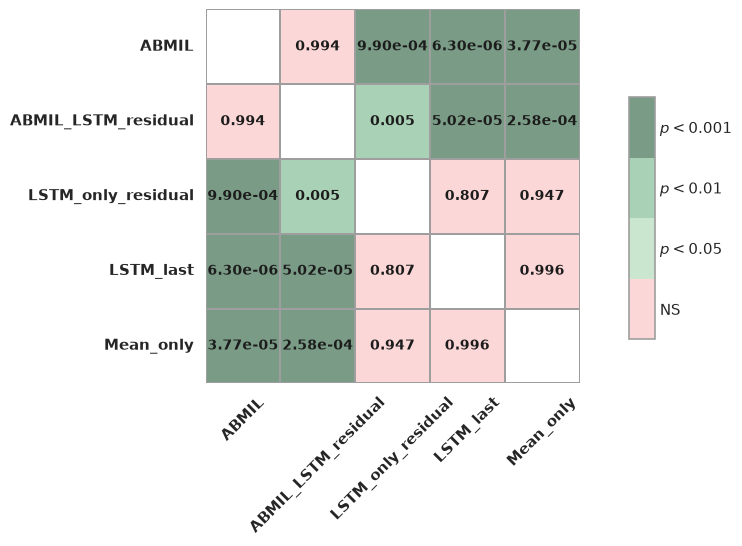

In [28]:
from src.mil_temporal_stats import compare_variants_per_encoder

results_abmil = {
    'perch2': results_ABMIL1,
}
results_abmil_lstm_residual = {
    'perch2': results_ABMIL_LSTM1,
}
results_lstm_residual = {
    'perch2': results_LSTM1,
}

results_lstm_last = {
    'perch2': results_Linear,
}

results_mean_only = {
    'perch2': results_Mean1,
}


df_stat = compare_variants_per_encoder(results_abmil, results_abmil_lstm_residual,
                                  results_lstm_residual, results_lstm_last,
                                  results_mean_only,
                                  label_names=None, alpha=0.05, plot=True)

Number of matched blocks (N): 125
Items compared: ['ABMIL', 'ABMIL_LSTM_residual', 'LSTM_only_residual', 'LSTM_last', 'Mean_only']
Friedman chi^2 statistic: 55.1786 | p-value: 2.9807e-11
Result: Significant difference detected (p < 0.05). Running Nemenyi post-hoc test.
Mean ranks (rank 1 = best): ABMIL=2.444, ABMIL_LSTM_residual=2.528, LSTM_only_residual=3.220, LSTM_last=3.440, Mean_only=3.368
Best-ranked item: ABMIL
Nemenyi Critical Difference (CD): 0.5456
Nemenyi pairwise p-value matrix:
                         ABMIL  ABMIL_LSTM_residual  LSTM_only_residual  LSTM_last  Mean_only
ABMIL                   1.0000               0.9935          9.9037e-04 6.3028e-06 3.7746e-05
ABMIL_LSTM_residual     0.9935               1.0000              0.0049 5.0228e-05 2.5832e-04
LSTM_only_residual  9.9037e-04               0.0049              1.0000     0.8066     0.9471
LSTM_last           6.3028e-06           5.0228e-05              0.8066     1.0000     0.9964
Mean_only           3.7746e-05     

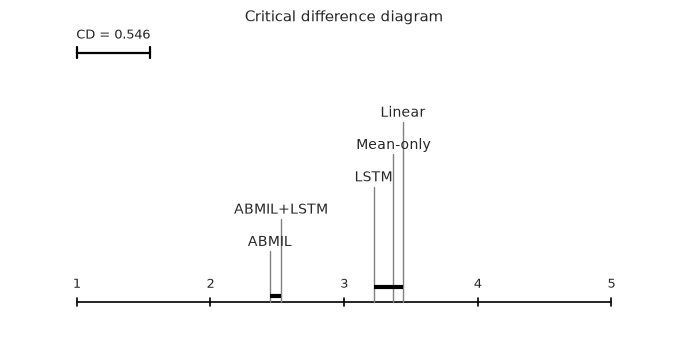

{'mean_ranks': ABMIL         2.444
 ABMIL+LSTM    2.528
 LSTM          3.220
 Mean-only     3.368
 Linear        3.440
 dtype: float64,
 'cd_value': np.float64(0.5455548741740753)}

In [34]:

from src.mil_temporal_stats import plot_critical_difference_diagram


plot_critical_difference_diagram(df_stat['perch2'],label_side = 'top', rename = {'ABMIL':'ABMIL', 'ABMIL_LSTM_residual':'ABMIL+LSTM', 'LSTM_only_residual':'LSTM', 'Mean_only':'Mean-only','LSTM_last':'Linear'})


=== Encoder: perch2 -- which MIL variant works best? (Friedman + Nemenyi) ===
[perch2] Number of matched blocks (N): 125
[perch2] Variants compared: ['ABMIL', 'ABMIL_LSTM_residual', 'LSTM_only_residual', 'LSTM_last']
[perch2] Friedman chi^2 statistic: 36.1538 | p-value: 6.9480e-08
[perch2] Result: Significant difference detected (p < 0.05). Running Nemenyi post-hoc test.
[perch2] Mean ranks (rank 1 = best): ABMIL=2.152, ABMIL_LSTM_residual=2.224, LSTM_only_residual=2.728, LSTM_last=2.896
[perch2] Best-ranked variant: ABMIL
[perch2] Nemenyi Critical Difference (CD): 0.5933
[perch2] Nemenyi pairwise p-value matrix:
                         ABMIL  ABMIL_LSTM_residual  LSTM_only_residual  LSTM_last
ABMIL                   1.0000               0.9714              0.0024 3.0888e-05
ABMIL_LSTM_residual     0.9714               1.0000              0.0109 2.2634e-04
LSTM_only_residual      0.0024               0.0109              1.0000     0.7325
LSTM_last           3.0888e-05           2.263

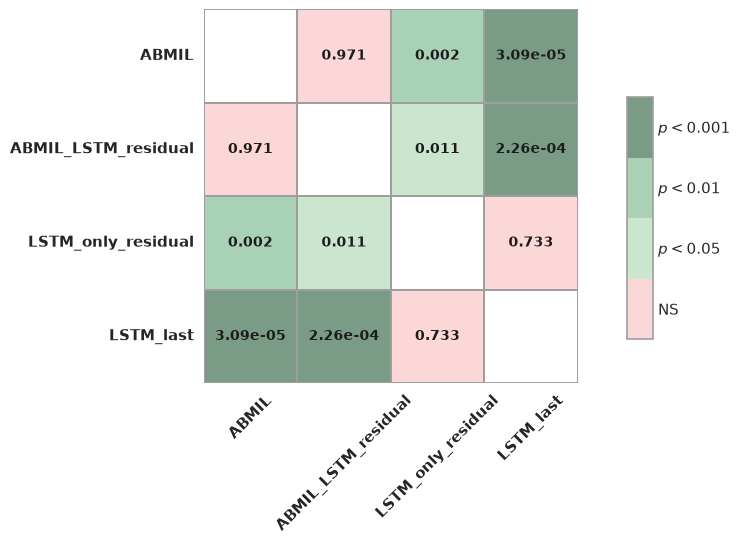

In [4]:
from src.statistical_analysis_augmentation import compare_variants_per_encoder


results_abmil_0 = {
    'perch2': results_ABMIL1,
}
results_abmil_lstm_residual_0 = {
    'perch2': results_ABMIL_LSTM1,
}
results_lstm_residual_0 = {
    'perch2': results_LSTM1,
}

results_lstm_last_0 = {
    'perch2': results_Linear,
}


per_encoder = compare_variants_per_encoder(
 results_abmil_0, results_abmil_lstm_residual_0, results_lstm_residual_0, results_lstm_last_0
)

Statistical analysis ensembling

In [26]:
from src.algo_comparison_new import compare_ensembled_vs_plain_pooled

compare_ensembled_vs_plain_pooled(
    results_ABMIL_LSTM1, results_ABMIL_LSTM, "ABMIL",
    label_cols=('type_a', 'type_b', 'type_c', 'type_d', 'echo'),
    alternative='greater',
)

,model,label,n_pairs,mean_ensemble,mean_plain,mean_diff,wilcoxon_stat,wilcoxon_p,note
0,ABMIL,pooled (all types),125,0.907686,0.893699,0.013986,2851.5,0.546392,


cmAP Evaluation

In [17]:
import pandas as pd
from sklearn.metrics import average_precision_score

def get_cmap_scores(results_list, as_dataframe=True):
    """
    Extracts per-(trial, fold) cmAP (macro-averaged AP across labels) scores
    from ONE algorithm's results list -- the format produced by
    abmil_classifier_tuned_optuna / linear_probe_tuned_optuna /
    abmil_classifier_quick / abmil_classifier_tuned, e.g. what you'd pass as
    `results_abmil` to the plotting/statistical-comparison functions.
    Recomputes cmAP directly from 'y_true_cv'/'y_pred_proba_cv' rather than
    reading 'mean_AP' off each trial dict, so you get one value per fold
    (not just the already-averaged-across-folds per-trial number) -- useful
    for eyeballing fold-to-fold variance, or feeding straight into the
    Friedman/Wilcoxon/plotting functions' expected block structure.
    Parameters
    ----------
    results_list : list of dict
        One algorithm's results (e.g. results_abmil). Each dict must have
        'trial', 'y_true_cv', 'y_pred_proba_cv' (fold-by-fold lists of
        (n_samples, n_labels) arrays) -- same schema as the other functions
        in this codebase already expect.
    as_dataframe : bool
        If True (default), return a pandas.DataFrame with columns
        ['trial', 'fold', 'cmAP']. If False, return a flat list of cmAP
        values (one per fold across all trials, in the same order).
    Returns
    -------
    pandas.DataFrame or list of float
    """
    rows = []
    for trial_dict in results_list:
        trial_idx = trial_dict.get('trial')
        y_true_folds = trial_dict['y_true_cv']
        y_pred_proba_folds = trial_dict['y_pred_proba_cv']
        for fold_idx in range(len(y_true_folds)):
            y_true = y_true_folds[fold_idx]
            y_pred_proba = y_pred_proba_folds[fold_idx]
            cmap = average_precision_score(y_true, y_pred_proba, average='macro')
            rows.append({'trial': trial_idx, 'fold': fold_idx, 'cmAP': cmap})
    if as_dataframe:
        return pd.DataFrame(rows)
    return [row['cmAP'] for row in rows]


In [18]:
df_cmap = get_cmap_scores(results2)
print(df_cmap['cmAP'].mean(), df_cmap['cmAP'].std(ddof=1))

0.8918805978712527 0.059616384121565134


Attention plot

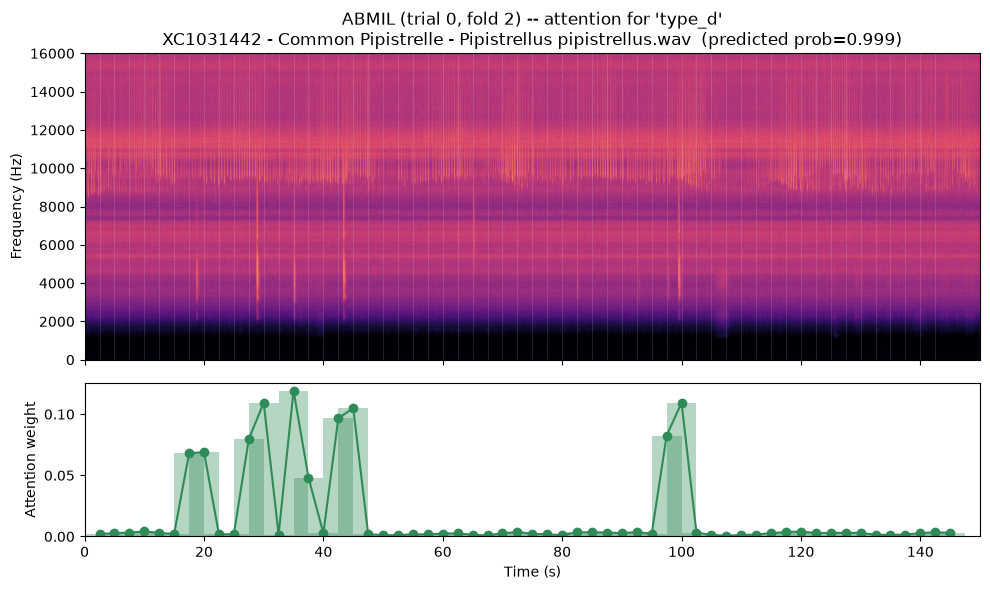

In [66]:
from src.attention_plots import plot_attention_grid,plot_attention_for_label
from src.preprocessing import PipistrellePreprocessingPipeline  # your actual import path
import pandas as pd

data_input = "/idiap/temp/adeych/data/bat_metadata.csv"
metadata_df = pd.read_csv(data_input)

# All four complex labels at once:
grid = plot_attention_for_label(
    results_ABMIL1, X_bags_pooled, metadata_df,label_name = 'type_d',
    variant='ABMIL', trial=0, fold=2,
    pipeline=PipistrellePreprocessingPipeline(target_sr=32000, expansion_factor=5,window_sec =5,overlap=0.5), file_path_col = 'relative_path'
    , dataset_path = "/idiap/temp/adeych/data/xenocanto-dataset"
)

OOD test of model

In [3]:
import argparse
import os
import sys
import onnxruntime as ort #verify difference between onnxruntime and onnxruntime-gpu
from huggingface_hub import hf_hub_download
from src.feature_generation import extract_feature, extract_encoder
from src.preprocessing import BioacousticDataset
import time
import numpy as np
from pathlib import Path
import pickle

from src.feature_generation import build_perch_fb

dir = Path("/idiap/temp/adeych/data")

batdata = BioacousticDataset(data_input=str(dir / "ood_metadata.csv"),
                         root_dir=str(dir / "domain-transfer-dataset"),
                         encoder = "perch2")
results = build_perch_fb(batdata,device='cuda')

Dataset type: <class 'src.preprocessing.BioacousticDataset'>


2026-09-01 20:56:56.167299331 [W:onnxruntime:Default, onnxruntime_pybind_state.cc:700 operator()] No registered plugin EP device found for 'CUDAExecutionProvider' with device_id=0
2026-09-01 20:56:56.311253645 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 2 Memcpy nodes are added to the graph perch_v2 for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.
Extracting perch 2.0: 100%|██████████| 673/673 [13:40<00:00,  1.22s/it]


In [ ]:
embeddings, labels = results

save_path = f"/idiap/temp/adeych/data/feature_banks/perch2_ood_features.pkl"
    
with open(save_path, "wb") as f:
    pickle.dump(embeddings, f)

save_path = f"/idiap/temp/adeych/data/feature_banks/perch2_ood_labels.pkl"
    
with open(save_path, "wb") as f:
    pickle.dump(labels, f)

In [3]:
import pickle 
from pathlib import Path
import numpy as np
from src.feature_generation import pool_features

with open(f"/idiap/temp/adeych/data/feature_banks/perch2_ood_features.pkl", "rb") as f:
    X_bags_ood = pickle.load(f)

X_bags_pooled_ood = pool_features(X_bags_ood,encoder = 'perch2')

In [6]:
from src.mil_multilabel_new_new import train_abmil_all_data
from src.ood_evaluation import evaluate_ood

final_model = train_abmil_all_data(X_bags_pooled, y, random_state=42, variant='ABMIL',
               hidden_dim=128, attention_dim=64, dropout=0.3,
               learning_rate=1e-4, weight_decay=1e-5,
               lstm_hidden_dim=None)


Training production model (ABMIL) on all available data...


[I 2026-09-07 17:48:09,165] A new study created in memory with name: ensemble_linear_probe_seed42
[I 2026-09-07 17:48:12,422] Trial 0 finished with value: 0.7097442680776015 and parameters: {'learning_rate': 5e-05, 'weight_decay': 1e-05, 'batch_size': 4}. Best is trial 0 with value: 0.7097442680776015.


In [9]:
import pandas as pd

data_input = "/idiap/temp/adeych/data/ood_metadata.csv"
metadata_df = pd.read_csv(data_input)

per_species_df, excluded_df, overall_df = evaluate_ood(
   final_model, X_bags_pooled_ood, metadata_df,min_n=4,
)
#0.652175 : ABMIL
#0.651124 : ABMIL + LSTM
print(overall_df)                                  # type_a..echo + cmAP, point estimates
print(per_species_df.sort_values('AP'))             # per (species, label) + 95% CI
print(excluded_df)                                  # species skipped (n < min_n) or unassigned


    label        AP
0  type_a  0.535179
1  type_b  0.353029
2  type_c  0.758909
3  type_d  0.838497
4    echo  0.800165
5    cmAP  0.657156
                      species   label    n  n_positive        AP    ci_low  \
13         Myotis daubentonii  type_b   27         1.0  0.071429  0.052632   
25           Nyctalus noctula  type_b   83         8.0  0.105414  0.053070   
22          Nyctalus leisleri    echo    7         1.0  0.166667  0.142857   
18          Nyctalus leisleri  type_a    7         1.0  0.200000  0.142857   
46           Plecotus auritus    echo   69        10.0  0.300267  0.128370   
32      Pipistrellus nathusii  type_c  336        56.0  0.412481  0.303802   
23          Nyctalus leisleri    cmAP    7         NaN  0.438360  0.428571   
43           Plecotus auritus  type_b   69        14.0  0.441226  0.197020   
31      Pipistrellus nathusii  type_b  336        33.0  0.472051  0.308074   
24           Nyctalus noctula  type_a   83         3.0  0.477778  0.201964   
37

In [8]:
from src.ood_evaluation import per_species_latex_table

per_species_latex_table(
    per_species_df, overall_df, excluded_df=None,
    label_cols=('type_a', 'type_b', 'type_c', 'type_d', 'echo'),
    label_display_names=None,
    decimals=3,
    caption="Out-of-distribution average precision (AP) by species and call type, "
            "with 95\\% bootstrap percentile confidence intervals.",
    table_label='tab:ood_ap_species',
    resize_to_fit=True,
    output_path='ood_ap_table.tex',
)

'% Requires \\usepackage{booktabs} in your preamble.\n% Requires \\usepackage{graphicx} in your preamble (for \\resizebox).\n\\begin{table}[htbp]\n\\centering\n\\caption{Out-of-distribution average precision (AP) by species and call type, with 95\\% bootstrap percentile confidence intervals.}\n\\label{tab:ood_ap_species}\n\\resizebox{\\textwidth}{!}{%\n\\begin{tabular}{l r ccccc c}\n\\toprule\nSpecies & $n$ & Type A & Type B & Type C & Type D & Echolocation & cmAP \\\\\n\\midrule\nEptesicus serotinus & 76 & 0.604 [0.188, 0.903] & 0.559 [0.350, 0.755] & 0.949 [0.902, 0.982] & -- & 0.826 [0.711, 0.949] & 0.735 [0.615, 0.838]$^\\dagger$ \\\\\nMyotis dasycneme & 14 & 0.835 [0.460, 1.000] & 0.609 [0.264, 0.917] & 0.656 [0.364, 0.914] & -- & 0.989 [0.941, 1.000] & 0.772 [0.607, 0.892]$^\\dagger$ \\\\\nMyotis daubentonii & 27 & 0.904 [0.706, 1.000] & 0.071 [0.053, 0.250] & 0.858 [0.688, 0.982] & -- & 0.964 [0.886, 1.000] & 0.699 [0.649, 0.962]$^\\dagger$ \\\\\nNyctalus leisleri & 7 & 0.200 [0